# 15 - Model Evaluation

> 📘 **Instructor Curriculum**

**What it is:** checking how good a trained model is, using data it has never seen.

**Why we need it:** a model always returns an answer. It never says *"I am not sure"*.
Only evaluation tells you whether that answer can be trusted.

**Why accuracy alone is not enough:** two models can both score 93%.
Model A's 8 mistakes send healthy people for an extra test.
Model B's 8 mistakes tell cancer patients they are fine.
Accuracy cannot tell those two apart. That is why the other metrics exist.

**What you get at the end:** not a better model - a decision, backed by numbers.

| Question | Metric that answers it |
| --- | --- |
| How often is it right? | accuracy |
| *Which* mistake does it make? | confusion matrix |
| When it says "cancer", is it right? | precision |
| Does it catch all the cancers? | recall |
| One number for both | F1 |

Dataset: breast cancer, 569 tumours. Predict **malignant (0)** or **benign (1)**.

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn import metrics

## Step 1 - Load the data

`load_breast_cancer()` returns a **`Bunch`** (a dict-like object), not a DataFrame.
That is why `data.info()` fails - `.info()` is a pandas method.

In [2]:
data = load_breast_cancer()
#data.info()  Can you check how can i porint the data details like columns and how many data you have 

In [3]:
# 1) straight from the Bunch
print("rows, columns  :", data.data.shape)
print("target names   :", data.target_names)      # ['malignant' 'benign'] -> 0, 1
print("first 5 columns:", list(data.feature_names[:5]))

# 2) or ask sklearn for a DataFrame and use pandas as usual
df = load_breast_cancer(as_frame=True).frame
df.info()
df["target"].value_counts()

rows, columns  : (569, 30)
target names   : ['malignant' 'benign']
first 5 columns: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness')]
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    f

target
1    357
0    212
Name: count, dtype: int64

Four facts to carry forward:

- 569 rows, 30 columns.
- **`0` = malignant (cancer), `1` = benign (safe).**
- 357 benign vs 212 malignant. Always answering "benign" already scores **63%**, so that is the floor to beat.
- scikit-learn treats **label `1` as positive** by default. Here `1` is benign, so to measure cancer detection you must pass `pos_label=0`.

## Step 2 - Split before you measure

Keep 20% of rows aside. The model never sees them while training.
Testing on training data is a memory test, not an ability test.

In [4]:
from sklearn.model_selection import train_test_split
X_train , X_test,Y_train, Y_test = train_test_split(data.data, data.target, test_size=0.20, random_state=0)

## Step 3 - Train a model

`GaussianNB` is Naive Bayes for continuous numbers - a fast baseline.
The model is not the point of this notebook. The **measuring** is.

## Step 4 - The first number

In [5]:
from sklearn.naive_bayes import GaussianNB
classfier1 = GaussianNB()
classfier1.fit(X_train,Y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[165.,290.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.36,0.64]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,0.0003431
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,30
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 30)","[[ 17.5 , 21.41,115.53,..., 0.18, 0.33, 0.09], [ 12.18, 17.87, 78.33,..., 0.08, 0.27, 0.08]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 30)","[[ 11.16, 12.2 ,515.95,..., 0. , 0.01, 0. ], [ 2.95, 15.6 ,129.89,..., 0. , 0. , 0. ]]"


In [6]:
classfier1.score(X_test,Y_test)

0.9298245614035088

`0.9298` = **106 correct out of 114**. Good.

But it does not say **which 8 were wrong**, and that is the only thing that matters here:

- healthy people flagged as cancer → an extra biopsy (annoying, survivable), or
- cancer patients told they are fine → they go home untreated.

Accuracy counts both as "one mistake". Reality does not.

## Step 5 - Predictions and accuracy by hand

In [7]:
Y_pred =classfier1.predict(X_test)
Y_pred

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 1])

In [8]:
metrics.accuracy_score(Y_pred,Y_test)

0.9298245614035088

> ⚠️ **Small fix:** the signature is `accuracy_score(y_true, y_pred)`, so write
> `metrics.accuracy_score(Y_test, Y_pred)`.
> For accuracy the order does not matter (matching is symmetric), but for
> `precision_score` and `recall_score` **swapping the arguments swaps the two
> metrics** - no error, just a wrong number. Get the habit right: true first.

## Step 6 - Confusion matrix

The four-box table from your notes. **Rows = truth, columns = guess.**

|  | Predicted malignant (0) | Predicted benign (1) |
| --- | --- | --- |
| **Actually malignant (0)** | ✅ TP | ❌ **FN** - missed cancer (Type II) |
| **Actually benign (1)** | ❌ FP - false alarm (Type I) | ✅ TN |

"Positive" just means *the class you are hunting*. Here that is malignant (0).

In [9]:
confusion_matrix = metrics.confusion_matrix(Y_test,Y_pred)
confusion_matrix

array([[43,  4],
       [ 4, 63]])

Your result `[[43, 4], [4, 63]]` in words:

- **43** cancers correctly caught (TP)
- **4** cancers called benign (FN) → **the dangerous box**
- **4** healthy called cancer (FP) → false alarm
- **63** healthy correctly cleared (TN)

Accuracy treats both `4`s as equal. A hospital does not.

## Step 7 - The same matrix as a picture

Your code passes `classfier1.classes_`, which shows `0` and `1`.
Tip: `display_labels=data.target_names` prints `malignant` / `benign` instead.

In [10]:
cm = metrics.ConfusionMatrixDisplay(confusion_matrix= confusion_matrix, display_labels=classfier1.classes_)


In [11]:
import matplotlib.pyplot as plt

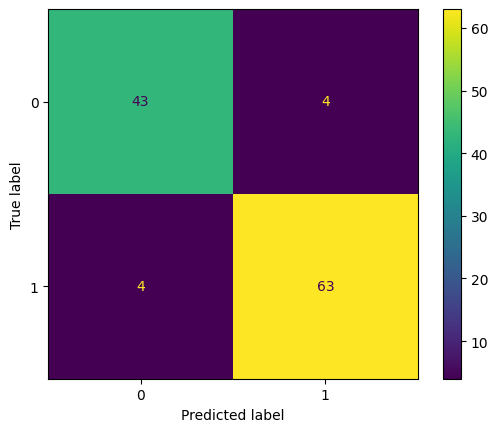

In [12]:
cm.plot()
plt.show()

## Step 8 - Precision, Recall, F1

All three come from the same four boxes (malignant = positive):

```text
Recall    = TP / (TP + FN)     "of all real cancers, how many did I catch?"
Precision = TP / (TP + FP)     "when I say cancer, how often am I right?"
F1        = 2PR / (P + R)      one number, high only when both are high
```

- **Recall** is hurt by misses (FN) → the metric a hospital cares about.
- **Precision** is hurt by false alarms (FP) → the metric a spam filter cares about.
- They pull against each other. Flag everything as cancer and recall hits 1.0 while precision collapses.

`classification_report` prints all of it, one row per class:

In [13]:
print(metrics.classification_report(Y_test, Y_pred, target_names=data.target_names, digits=3))

              precision    recall  f1-score   support

   malignant      0.915     0.915     0.915        47
      benign      0.940     0.940     0.940        67

    accuracy                          0.930       114
   macro avg      0.928     0.928     0.928       114
weighted avg      0.930     0.930     0.930       114



How to read it:

- **Read the `malignant` row first** - recall `0.915` means we catch 91.5% of cancers and miss 8.5%.
- **`support`** = how many real rows of that class were tested (47 and 67).
- **`macro avg`** = plain mean of both rows. **`weighted avg`** = weighted by support, so it flatters you on imbalanced data (notice it equals the accuracy we started with).

---

## Common mistakes

1. Reporting accuracy on imbalanced data - here "always benign" scores 63% with no model.
2. Swapping the arguments: `y_true` comes first.
3. Forgetting sklearn's positive class is `1`. Here `1` is benign, so use `pos_label=0` for cancer.
4. Trusting one split - see [11_Corss_validation.ipynb](11_Corss_validation.ipynb).

## Key takeaway

> **If you remember only one thing...**
> Accuracy tells you *how often* the model is wrong. The confusion matrix tells you
> *what it costs*. Only the second one lets you decide whether to use the model.

Next step: these metrics use a fixed 0.50 cut-off. The ROC curve checks
**every** cut-off at once → [14_roc.ipynb](14_roc.ipynb).